#  **Task 3 — Titanic Survival Prediction**

# **🚢 Titanic Survival Prediction Using Logistic Regression**

**Author:** Shoaib Muhammad  
**Internship:** Neurofive Solutions — Machine Learning Track  
**Task:** Build Your First Machine Learning Model  
**Dataset:** Titanic - Machine Learning from Disaster

## **🎯 Objective**

The goal of this task is to build a machine learning classification model that predicts whether a Titanic passenger survived or did not survive. Logistic Regression is used as the classification algorithm. The dataset is split into training and testing sets, categorical features are encoded, and the model is evaluated using accuracy and a confusion matrix.

# **Import Libraries**

In [ ]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# **Load** **the** **Titanic** **dataset**

In [9]:
# Load the Titanic dataset

df = pd.read_csv("train.csv")

# Display the first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# **Clean the Dataset**

In [17]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the most frequent value
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because it contains many missing values, but only if it exists
if 'Cabin' in df.columns:
    df = df.drop(columns=["Cabin"])

# Display DataFrame info after cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [18]:
# Check remaining missing values

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **Select Features and Target**

In [19]:
# Select features

X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
]

# Select target variable

y = df["Survived"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (891, 7)
Target shape: (891,)


# **Split Training and Testing Data**

The dataset is divided into training and testing sets. The model learns patterns from the training data, while the test data is kept separate to evaluate how well the model performs on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 712
Testing samples: 179


# **Identify Categorical and Numerical Columns**

In [23]:
# Identify categorical and numerical columns

categorical_features = ["Sex", "Embarked"]

numerical_features = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Sex', 'Embarked']
Numerical features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create OneHotEncoder for categorical columns

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

# **Create Logistic Regression Model**

Logistic Regression is a classification algorithm used to predict categories. In this project, the model predicts two possible outcomes: `0` for did not survive and `1` for survived.

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

# **Train the Model**

In [31]:
# Train the Logistic Regression model

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


# **Make Predictions**

After training, the model is used to predict survival outcomes for passengers in the test dataset. The test data was not used during training, so it provides an estimate of how the model performs on unseen data.

In [32]:
# Make predictions on the test dataset

y_pred = model.predict(X_test)

# Display the first 10 predictions

print("Predictions:", y_pred[:10])

Predictions: [0 0 0 0 1 0 1 0 0 0]


# **Calculate Accuracy**

In [34]:
from sklearn.metrics import accuracy_score

# Calculate model accuracy

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 80.45%


# **Confusion Matrix**

A confusion matrix shows how the classification model performed by comparing the actual survival outcomes with the model's predictions.

It contains four possible results:

- **True Negative (TN):** Correctly predicted did not survive.
- **True Positive (TP):** Correctly predicted survived.
- **False Positive (FP):** Predicted survived, but the passenger did not survive.
- **False Negative (FN):** Predicted did not survive, but the passenger actually survived.

In [36]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[98 12]
 [23 46]]


# **Visualize Confusion Matrix**

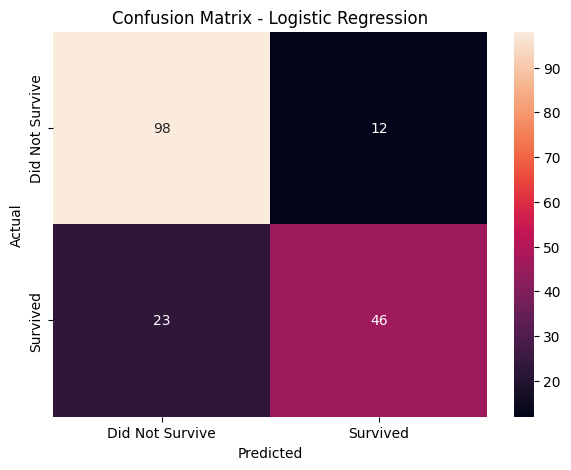

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the confusion matrix

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"]
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#  **Confusion Matrix Interpretation**

___

The confusion matrix shows the number of correct and incorrect survival predictions made by the Logistic Regression model. The diagonal values represent correct predictions, while the other values represent incorrect predictions. True Negatives are passengers correctly predicted not to survive, and True Positives are passengers correctly predicted to survive. False Positives and False Negatives represent cases where the model's prediction did not match the actual outcome.

# **Final Results**

In [39]:
# Display final model accuracy

print(f"Final Test Accuracy: {accuracy:.2%}")

Final Test Accuracy: 80.45%


# **Conclusion**
---

In this task, I built my first machine learning classification model using Logistic Regression. The Titanic dataset was divided into training and testing sets, and categorical features were converted using OneHotEncoder. The model was trained to predict whether a passenger survived or did not survive. Its performance was evaluated using accuracy score and a confusion matrix. This task helped me understand the basic workflow of preparing data, training a classification model, making predictions, and evaluating model performance.